In [1]:
#auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from Deactylation import Deacetylation
from constants import *
import numpy as np
import matplotlib.pyplot as plt
from regression import get_A_from_k_ref
import pickle
from sklearn.metrics import r2_score
from multiprocessing import Pool
import os

"""
Plot preferences
"""
plt.rc('font', family='serif', serif='Times New Roman')
plt.rc('text', usetex=False)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('axes', labelsize=18)
"""
data processing
"""

markerlist = ['o','v','s','h','X','D','P','^','<','>','p','*']

localdbpath='./datapickles/'
exp_path='./DAPermeability/'

In [3]:
data_t_naoh = pickle.load(open('./data/data.pkl', 'rb'))

In [4]:
temperature_lst = []
NaOH_loading_lst = []
Lignin_yield_lst = []
Acetyl_yield_lst = []
for d in data_t_naoh:
    temperature_lst.append(d['temperature'])
    NaOH_loading_lst.append(d['NaOH_loading'])
    Lignin_yield_lst.append(d['Lignin_yield'][-1])
    Acetyl_yield_lst.append(d['Acetyl_yield'][-1])

print(f"temperature_lst: {temperature_lst}")
print(f"NaOH_loading_lst: {NaOH_loading_lst}")
print(f"Lignin_yield_lst: {Lignin_yield_lst}")
print(f"Acetyl_yield_lst: {Acetyl_yield_lst}")


print("formatted for latex table:")
for i in range(len(temperature_lst)):
    print(f"{temperature_lst[i]} & {NaOH_loading_lst[i]} & {Lignin_yield_lst[i]*100:.2f} & {Acetyl_yield_lst[i]*100:.2f} \\\\ [0.5ex]")


temperature_lst: [50, 60, 70, 80, 90, 90, 90]
NaOH_loading_lst: [66.7, 66.7, 66.7, 66.7, 66.7, 46.7, 86.7]
Lignin_yield_lst: [0.15621469050677944, 0.24163466374182982, 0.2973499245544823, 0.38092281577346104, 0.4323988719590638, 0.24829627101290777, 0.5825878358888227]
Acetyl_yield_lst: [0.9492192876670107, 0.9584762386176512, 0.9776388969420718, 1.0, 1.0, 0.9494916930292986, 1.0]
formatted for latex table:
50 & 66.7 & 15.62 & 94.92 \\ [0.5ex]
60 & 66.7 & 24.16 & 95.85 \\ [0.5ex]
70 & 66.7 & 29.73 & 97.76 \\ [0.5ex]
80 & 66.7 & 38.09 & 100.00 \\ [0.5ex]
90 & 66.7 & 43.24 & 100.00 \\ [0.5ex]
90 & 46.7 & 24.83 & 94.95 \\ [0.5ex]
90 & 86.7 & 58.26 & 100.00 \\ [0.5ex]


In [5]:
da = Deacetylation()

# Baysian estimation of parameters

In [6]:
import emcee
from regression import run_simulation, optimize_parameters
import tqdm
import corner
from mcmc import run_all

11:24:42 INFO:arviz_base not installed
11:24:42 INFO:arviz_stats not installed
11:24:42 INFO:arviz_plots not installed


In [ ]:
posterior_samples, sampler =run_all(nwalkers=128,chain_length=15000)

In [ ]:
x0 = [np.log(1e-2), 40, np.log(1e-1), 20, 0.2, 1.0, 1.0,]  # Initial guess for ln(k_ref_lig), Ea_lig, ln(k_ref_ace), Ea_ace, b_lig, n_lig, n_ace
lb = [np.log(1e-5), 20, np.log(1e-5), 0, 0.1, 0.5, 0.5]  # Lower bounds for ln(k_ref_lig), Ea_lig, ln(k_ref_ace), Ea_ace, b_lig, n_lig, n_ace
ub = [np.log(1e2), 100, np.log(1e2), 40, 0.8, 2.0, 2.0]  # Upper bounds for ln(k_ref_lig), Ea_lig, ln(k_ref_ace), Ea_ace, b_lig, n_lig, n_ace

sigma_lb = 0.001 # Minimum noise level (1% yield error)
sigma_ub = 0.1   # Maximum noise level (10% yield error)    
sigma_0 = 0.05   # Initial guess for noise level (5% yield error)

def log_prior(theta):
    # theta = [ln_k_ref_lig, Ea_lig, ln_k_ref_ace, Ea_ace, b_lignin, gamma, n, sigma]
    # Note: We add 'sigma' (noise level) as a parameter to be estimated!
    
    ln_k_lig, Ea_lig, ln_k_ace, Ea_ace, b_lig, gamma, n, sigma = theta
    
    # Check bounds (similar to your 'lb' and 'ub')
    if (lb[0] < ln_k_lig < ub[0] and lb[1] < Ea_lig < ub[1] and 
        lb[2] < ln_k_ace < ub[2] and lb[3] < Ea_ace < ub[3] and 
        lb[4] < b_lig < ub[4] and lb[5] <= gamma < ub[5] and 
        lb[6] < n < ub[6] and sigma_lb < sigma < sigma_ub):
        return 0.0 # uniform prior (equal probability within bounds)
    return -np.inf # impossible parameter set

def log_likelihood(theta, experimental_data):
    # Unpack parameters (excluding sigma for the simulation run)
    params_for_sim = theta[:-1] 
    sigma = theta[-1] # The standard deviation of the noise (unknown)
    
    # Run your existing simulation function
    # Note: run_simulation must return the RAW residuals (exp - pred), not squared
    residuals = run_simulation(params_for_sim) 
    
    # Calculate Gaussian likelihood
    # Ln(L) = -0.5 * sum( (residual/sigma)^2 + ln(2*pi*sigma^2) )
    n_points = len(residuals)
    log_l = -0.5 * np.sum((residuals / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))
    return log_l

def log_probability(theta, experimental_data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, experimental_data)

def run_mcmc(initial_guess):
    # Setup
    ndim = 8  # number of parameters (7 kinetic + 1 sigma)
    nwalkers = 32 # number of parallel chains
    nsteps = 5000 # how many steps to take (increase for better results)
    
    # Initialize walkers in a tiny ball around your best guess (from least_squares)
    # Append a guess for sigma (e.g., 0.05 yield error) to your existing best_params
    initial_guess_with_sigma = np.append(initial_guess, 0.05)
    pos = initial_guess_with_sigma + 1e-4 * np.random.randn(nwalkers, ndim)

    # Run emcee
    # sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(data_t_naoh,))
    # print("Running MCMC...")
    # sampler.run_mcmc(pos, nsteps, progress=True)
    ncpu = os.cpu_count() - 2 
    print(f"Using {ncpu} CPUs")

    with Pool(processes=ncpu) as pool:
        
        # Pass the pool to the sampler
        sampler = emcee.EnsembleSampler(
            nwalkers, 
            ndim, 
            log_probability, 
            args=(data_t_naoh,), 
            pool=pool # <--- This is the magic argument
        )

        sampler.run_mcmc(pos, nsteps, progress=True)
    
    # Discard "burn-in" (the first 300 steps where it's finding the groove)
    flat_samples = sampler.get_chain(discard=400, thin=15, flat=True)
    return flat_samples, sampler



In [ ]:
results = optimize_parameters(x0, lb, ub)
best_params = results.x
print("Best parameters from optimization:", best_params)
posterior_samples, sampler = run_mcmc(best_params)

## Save result / load reasult

The sampler object is too large for GitHub. Any code using smapler object below will break without running the run_all() code cell above.

In [ ]:
# save posterior samples and sampler object for future analysis
# with open('./output/posterior_samples.pkl', 'wb') as f:
#     pickle.dump(posterior_samples, f)
# with open('./output/sampler.pkl', 'wb') as f:
#     pickle.dump(sampler, f)

In [ ]:
posterior_samples = pickle.load(open('./data/posterior_samples.pkl', 'rb'))
# the sampler object is too large for Github. Any 
# sampler = pickle.load(open('./data/sampler.pkl', 'rb'))

In [9]:
# Calculate the autocorrelation time (tau)
tau = sampler.get_autocorr_time()
print(f"Autocorrelation time for each parameter: {tau}")

# Get the maximum tau across all your parameters
max_tau = np.max(tau)

# Calculate dynamic burn-in and thinning
burnin = int(2 * max_tau)
thinning = int(0.5 * max_tau) # take every Nth step to reduce file size/correlation

print(f"burn in: {burnin} steps, thinning: every {thinning} steps")
# print(f"Recommended discard: {burnin} steps")
# flat_samples = sampler.get_chain(discard=burnin, thin=thinning, flat=True)

Autocorrelation time for each parameter: [104.90510129 102.28997744  97.80468258  94.278188   103.46967074
 105.56778093  98.31137426  78.33751246  94.16864805]
burn in: 211 steps, thinning: every 52 steps


In [88]:
posterior_samples = sampler.get_chain(discard=400, thin=52, flat=True)

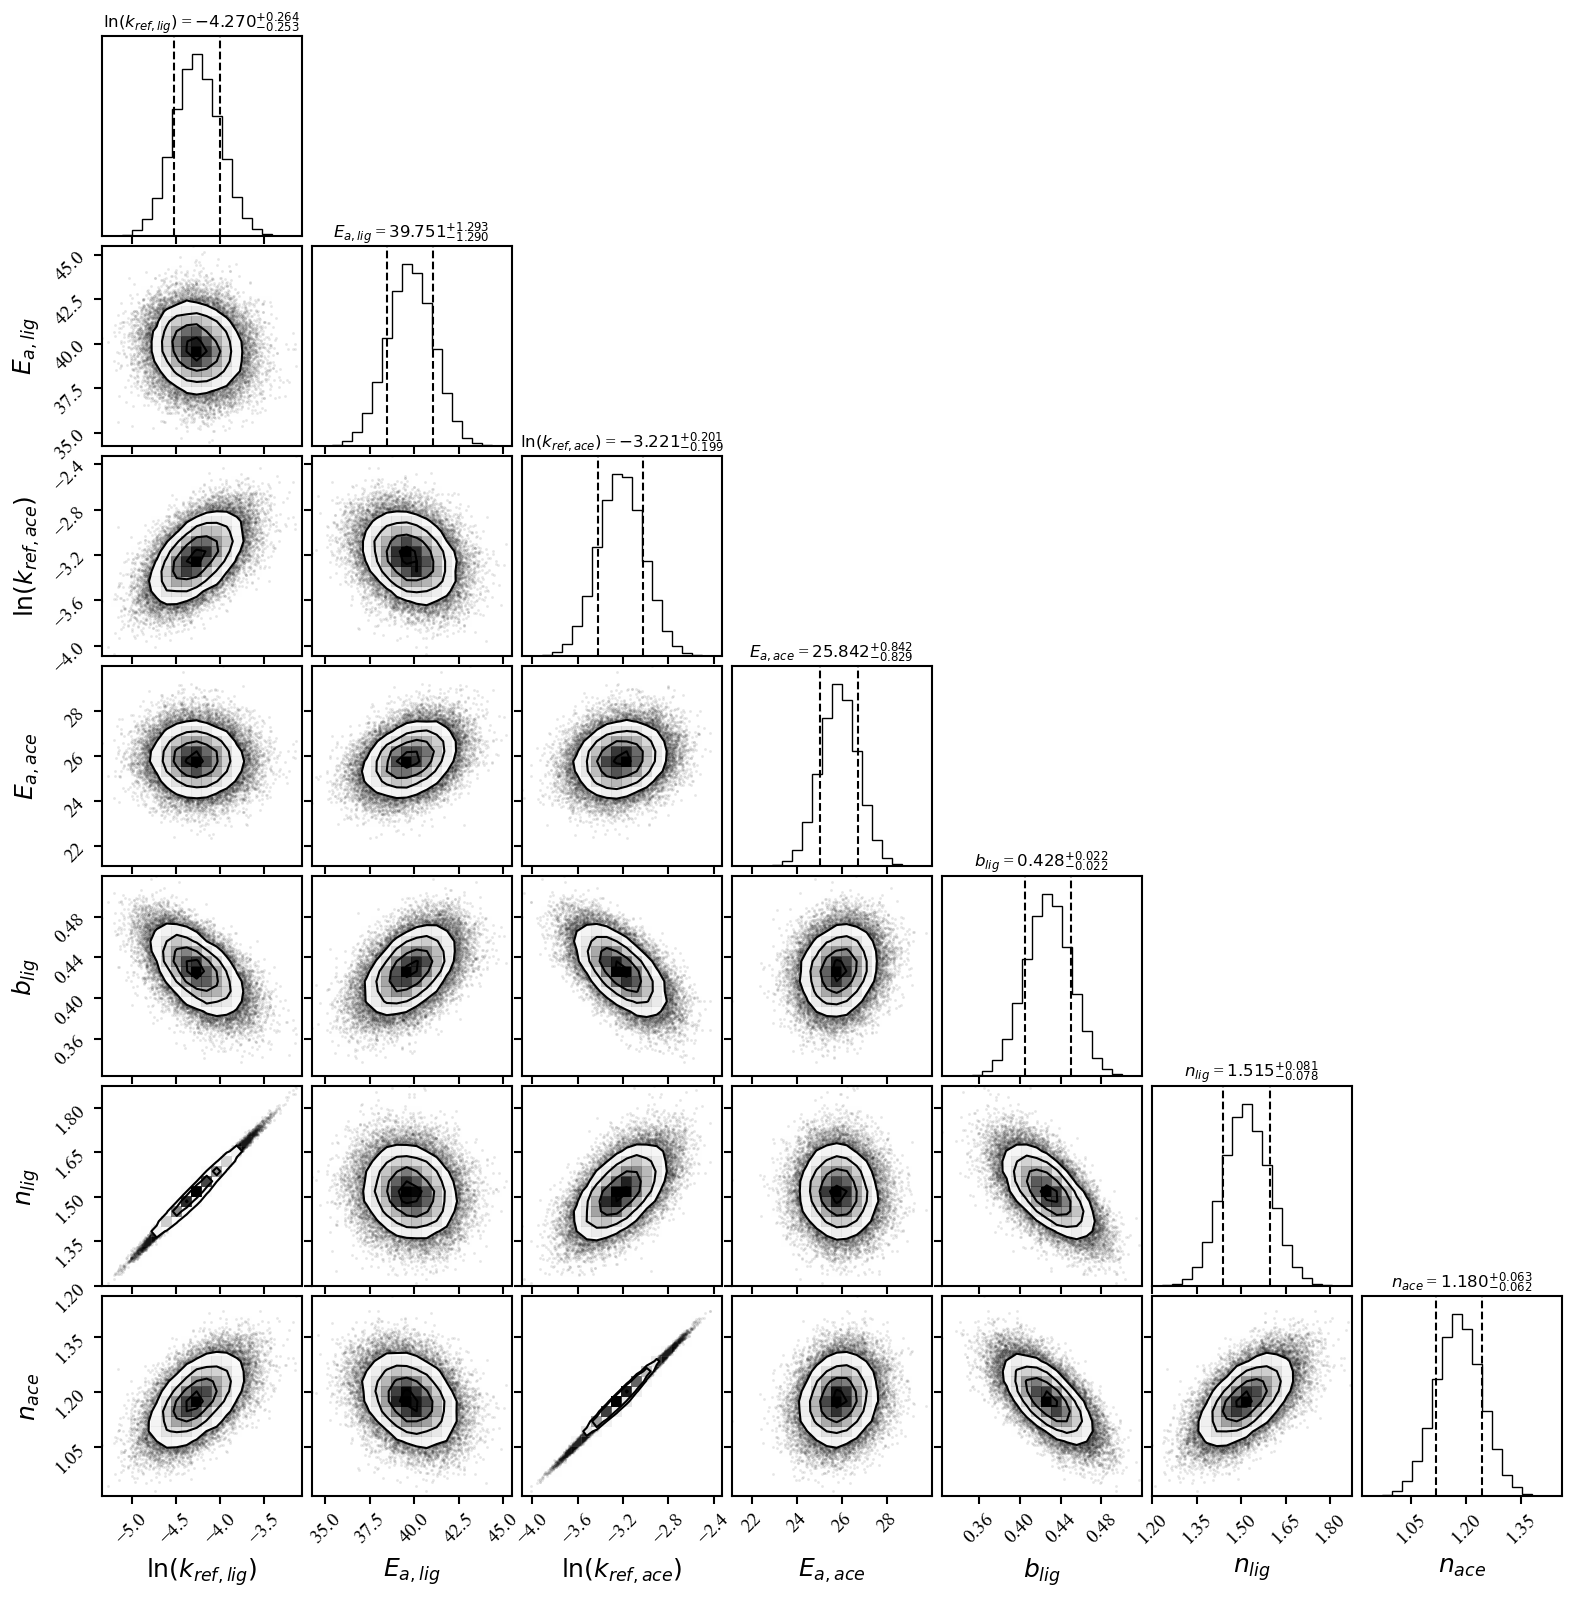

In [118]:
# 1. Define your labels (Must match the order in your 'theta' vector!)
labels = [
    r"$\ln(k_{ref, lig})$", 
    r"$E_{a, lig}$", 
    r"$\ln(k_{ref, ace})$", 
    r"$E_{a, ace}$", 
    r"$b_{lig}$", 
    r"$n_{lig}$", 
    r"$n_{ace}$", 
]

# plt.rc('font', family='serif', serif='Times New Roman')
# plt.rc('text', usetex=False)
# plt.rc('xtick', labelsize=18)
# plt.rc('ytick', labelsize=18)
# plt.rc('axes', labelsize=18)
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'

plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'font.serif': 'Times New Roman'})

# 2. Generate the plot
# flat_samples is the result from sampler.get_chain(flat=True)
fig = corner.corner(
    posterior_samples[:, :-2], 
    labels=labels, 
    show_titles=True,       
    quantiles=[0.16, 0.84],            # Used for the vertical dashed lines on the plot
    title_quantiles=[0.16, 0.5, 0.84], # REQUIRED: [16th, 50th, 84th] for "Median +Error -Error"
    title_fmt='.3f',
    label_kwargs={"fontsize": 18, "fontweight": 'bold', "fontname": "Times New Roman"}
)
# fig.subplots_adjust(right=0.95, top=0.95, hspace=0.1, wspace=0.1)
for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1.5, labelsize=14)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)

plt.savefig('./output/Corner_plot_MCMC.png', dpi=300, bbox_inches='tight')

In [ ]:
from IPython.display import display, Math # For pretty printing in Jupyter

print("--- Final MCMC Parameters ---")

# Iterate through each parameter
for i in range(posterior_samples.shape[1]):
    # Calculate percentiles
    mcmc = np.percentile(posterior_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc) # Calculate differences: (50th - 16th) and (84th - 50th)
    
    # Identify the parameter name
    name = labels[i]
    
    # Text format: Value +UpperError -LowerError
    txt = f"{name}: {mcmc[1]:.3f} (+{q[1]:.3f} / -{q[0]:.3f})"
    print(txt)

    # Optional: If you want parameters for your simulation code
    if "lig" in name and "ln" in name:
        best_lnk_lig = mcmc[1]
    elif "Ea_lig" in name:
        best_Ea_lig = mcmc[1]
        
# The 'mcmc[1]' values are your robust "Best Fit" parameters to use in future simulations.

--- Final MCMC Parameters ---
$\ln(k_{ref, lig})$: -4.564 (+0.179 / -0.154)
$E_{a, lig}$: 41.466 (+0.809 / -0.852)
$\ln(k_{ref, ace})$: -3.441 (+0.258 / -0.236)
$E_{a, ace}$: 25.908 (+1.628 / -1.687)
$b_{lignin}$: 0.481 (+0.011 / -0.013)
$n_{lignin}$: 1.409 (+0.054 / -0.047)
$n_{ace}$: 1.100 (+0.077 / -0.069)
$\sigma$ (noise): 0.059 (+0.003 / -0.002)


In [112]:
best_params_ls = [-4.17463817, 38.7608427, -3.08951253, 25.66577467, 0.40194738, 1.55263, 1.22416378]
labels = [
    r"$\ln(k_{ref, lig})$", 
    r"$E_{a, lig}$", 
    r"$\ln(k_{ref, ace})$", 
    r"$E_{a, ace}$", 
    r"$b_{lignin}$", 
    r"$n_{lignin}$", 
    r"$n_{ace}$", 
    r"$\sigma_lig$",
    r"$\sigma_ace$"
    
]
mcmc_lst = []
q_lst = []
for i in range(posterior_samples.shape[1]):
    # mcmc = np.percentile(posterior_samples[:, i], [16, 50, 84])
    # 95 confidence interval
    mcmc = np.percentile(posterior_samples[:, i], [2.5, 50, 97.5])
    q = np.diff(mcmc)
    name = labels[i]
    txt = f"{name}: {mcmc[1]:.3f} (+{q[1]:.3f} / -{q[0]:.3f})"
    mcmc_lst.append(mcmc)
    q_lst.append(q)
    print(txt)

ln_kref_lig_mcmc, Ea_lig_mcmc, ln_kref_ace_mcmc, Ea_ace_mcmc, b_lig_mcmc, n_lig_mcmc, n_ace_mcmc, sigma_lig_mcmc, sigma_ace_mcmc = mcmc_lst

from regression import T_ref
A_lig_mcmc = get_A_from_k_ref(np.exp(ln_kref_lig_mcmc), Ea_lig_mcmc, T_ref=T_ref)
A_ace_mcmc = get_A_from_k_ref(np.exp(ln_kref_ace_mcmc), Ea_ace_mcmc, T_ref=T_ref)

q_A_lig = np.diff(A_lig_mcmc)
q_A_ace = np.diff(A_ace_mcmc)
q_Ea_lig = np.diff(Ea_lig_mcmc)
q_Ea_ace = np.diff(Ea_ace_mcmc) 
q_b_lig = np.diff(b_lig_mcmc)
q_n_lig = np.diff(n_lig_mcmc)
q_n_ace = np.diff(n_ace_mcmc)
q_sigma_lig = np.diff(sigma_lig_mcmc)
q_sigma_ace = np.diff(sigma_ace_mcmc)

ln_kref_lig_ls, Ea_lig_ls, ln_kref_ace_ls, Ea_ace_ls, b_lig_ls, n_lig_ls, n_ace_ls = best_params_ls  #best_params
A_lig_ls = get_A_from_k_ref(np.exp(ln_kref_lig_ls), Ea_lig_ls, T_ref=T_ref)
A_ace_ls = get_A_from_k_ref(np.exp(ln_kref_ace_ls), Ea_ace_ls, T_ref=T_ref) 

# print in latex table : least squares best fit with MCMC best fit and error bars  with each row being a parameter name, least squares best fit, MCMC best fit ^{+error}_{-error}
print("\n--- LaTeX Table ---")
print("\\begin{tabular}{lcc}")
print('\\toprule')
print("Parameter & Least Squares Best Fit & MCMC Best Fit \\\\[0.5ex]")
print('\\midrule')
print(f"$A_{{lig}}$ & {A_lig_ls:.2e} & ${A_lig_mcmc[1]:.2e}^{{+{q_A_lig[1]:.2e}}}_{{-{q_A_lig[0]:.2e}}}$ \\\\[0.5ex]")
print(f"$E_{{a, lig}}$ & {Ea_lig_ls:.2f} & ${Ea_lig_mcmc[1]:.2f}^{{+{q_Ea_lig[1]:.2f}}}_{{-{q_Ea_lig[0]:.2f}}}$ \\\\[0.5ex]")
print(f"$A_{{ace}}$& {A_ace_ls:.2e} & ${A_ace_mcmc[1]:.2e}^{{+{q_A_ace[1]:.2e}}}_{{-{q_A_ace[0]:.2e}}}$ \\\\[0.5ex]")
print(f"$E_{{a, ace}}$  & {Ea_ace_ls:.2f} & ${Ea_ace_mcmc[1]:.2f}^{{+{q_Ea_ace[1]:.2f}}}_{{-{q_Ea_ace[0]:.2f}}}$ \\\\[0.5ex]")
print(f"$b_{{lignin}}$ & {b_lig_ls:.2f} & ${b_lig_mcmc[1]:.2f}^{{+{q_b_lig[1]:.2f}}}_{{-{q_b_lig[0]:.2f}}}$ \\\\[0.5ex]")
print(f"$n_{{lignin}}$ & {n_lig_ls:.2f} & ${n_lig_mcmc[1]:.2f}^{{+{q_n_lig[1]:.2f}}}_{{-{q_n_lig[0]:.2f}}}$ \\\\[0.5ex]")
print(f"$n_{{ace}}$ & {n_ace_ls:.2f} & ${n_ace_mcmc[1]:.2f}^{{+{q_n_ace[1]:.2f}}}_{{-{q_n_ace[0]:.2f}}}$ \\\\[0.5ex]")
print(f"$\\sigma$ &NA & ${sigma_lig_mcmc[1]:.3f}^{{+{q_sigma_lig[1]:.3f}}}_{{-{q_sigma_lig[0]:.3f}}}$ \\\\[0.5ex]")
print(f"$\\sigma$ &NA & ${sigma_ace_mcmc[1]:.3f}^{{+{q_sigma_ace[1]:.3f}}}_{{-{q_sigma_ace[0]:.3f}}}$ \\\\[0.5ex]")
print('\\bottomrule')
print("\\end{tabular}") 

$\ln(k_{ref, lig})$: -4.270 (+0.524 / -0.502)
$E_{a, lig}$: 39.751 (+2.533 / -2.609)
$\ln(k_{ref, ace})$: -3.221 (+0.400 / -0.398)
$E_{a, ace}$: 25.842 (+1.682 / -1.661)
$b_{lignin}$: 0.428 (+0.044 / -0.044)
$n_{lignin}$: 1.515 (+0.161 / -0.152)
$n_{ace}$: 1.180 (+0.125 / -0.124)
$\sigma_lig$: 0.019 (+0.003 / -0.003)
$\sigma_ace$: 0.026 (+0.004 / -0.004)

--- LaTeX Table ---
\begin{tabular}{lcc}
\toprule
Parameter & Least Squares Best Fit & MCMC Best Fit \\[0.5ex]
\midrule
$A_{lig}$ & 1.22e+04 & $1.57e+04^{+4.88e+04}_{-1.19e+04}$ \\[0.5ex]
$E_{a, lig}$ & 38.76 & $39.75^{+2.53}_{-2.61}$ \\[0.5ex]
$A_{ace}$& 3.67e+02 & $3.43e+02^{+5.80e+02}_{-2.14e+02}$ \\[0.5ex]
$E_{a, ace}$  & 25.67 & $25.84^{+1.68}_{-1.66}$ \\[0.5ex]
$b_{lignin}$ & 0.40 & $0.43^{+0.04}_{-0.04}$ \\[0.5ex]
$n_{lignin}$ & 1.55 & $1.52^{+0.16}_{-0.15}$ \\[0.5ex]
$n_{ace}$ & 1.22 & $1.18^{+0.12}_{-0.12}$ \\[0.5ex]
$\sigma$ &NA & $0.019^{+0.003}_{-0.003}$ \\[0.5ex]
$\sigma$ &NA & $0.026^{+0.004}_{-0.004}$ \\[0.5ex]
\bottomr

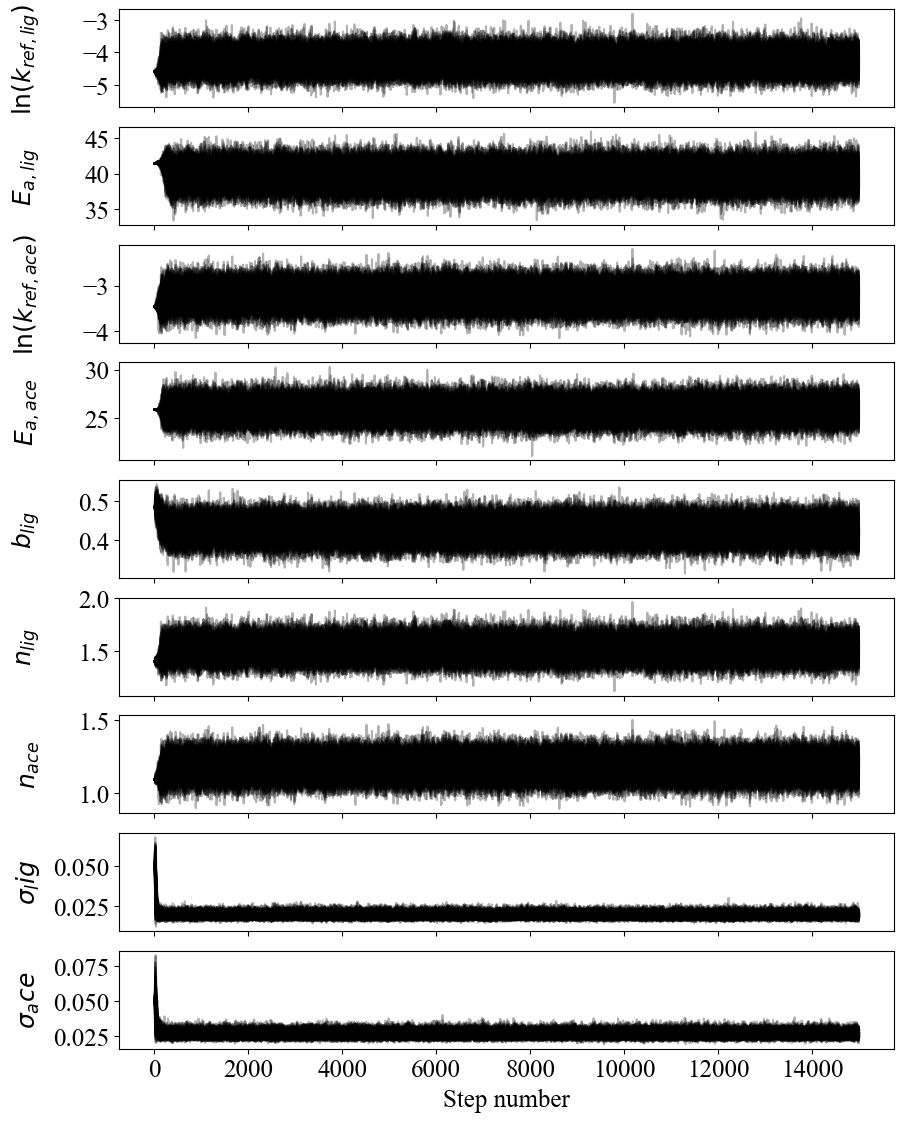

In [119]:
labels = [
    r"$\ln(k_{ref, lig})$", 
    r"$E_{a, lig}$", 
    r"$\ln(k_{ref, ace})$", 
    r"$E_{a, ace}$", 
    r"$b_{lig}$", 
    r"$n_{lig}$", 
    r"$n_{ace}$", 
    r"$\sigma_lig$",
    r"$\sigma_ace$"
]

chains = sampler.get_chain() # Shape: (nsteps, nwalkers, ndim)
ndim = chains.shape[2]

fig, axes = plt.subplots(ndim, 1, figsize=(10, 1.5 * ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]
    # Plot the chains for every walker
    ax.plot(chains[:, :, i], "k", alpha=0.3) 
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Step number")
# plt.show()

plt.savefig('./output/MCMC_chains.png', dpi=300, bbox_inches='tight')

In [97]:
def get_paramdict_from_theta(theta):
    ln_k_lig, Ea_lig_kJ, ln_k_ace, Ea_ace_kJ, b_lig, n_lig, n_ace, sigma_lig, sigma_ace = theta
        
    A_lig = get_A_from_k_ref(np.exp(ln_k_lig), Ea_lig_kJ, T_ref=T_ref)
    A_ace = get_A_from_k_ref(np.exp(ln_k_ace), Ea_ace_kJ, T_ref=T_ref)  

    parameters = {
        'A_lig': A_lig,
        'Ea_lig': Ea_lig_kJ,
        'A_ace': A_ace, 
        'Ea_ace': Ea_ace_kJ,
        'b_lig': b_lig,
        'n_lig': n_lig,
        'n_ace': n_ace
    }
    return parameters

In [98]:
def run_simulations_sampled_from_posterior(posterior_samples, experimental_data):
    all_residuals = []
    for theta in posterior_samples:
        params = get_paramdict_from_theta(theta)
        residuals = run_simulation(params) # This should return the raw residuals (exp - pred)
        all_residuals.append(residuals)
    return np.array(all_residuals)

Generating uncertainty bands using 100 posterior samples...


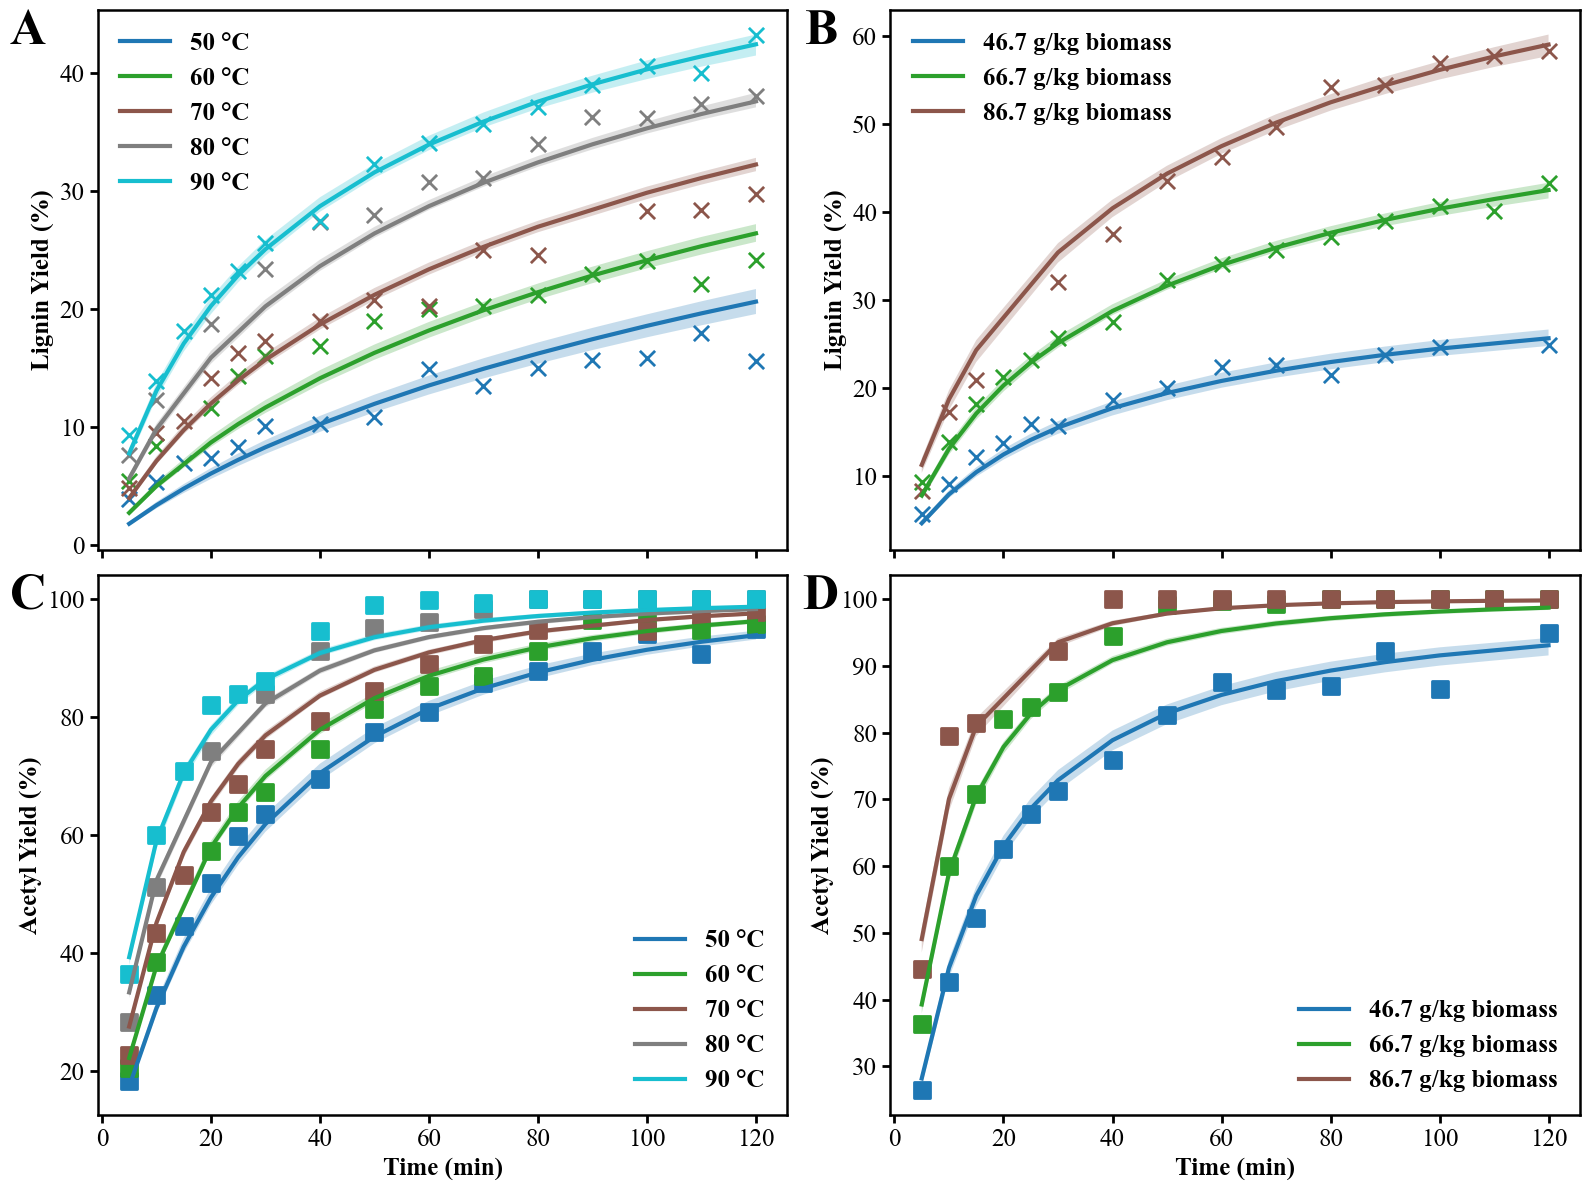

In [99]:
save = True
R = 8.314
T_ref = 70 + 273.15  # Reference Temp in K

# 2. Pick 100 random samples from your posterior distribution
# Assuming 'flat_samples' is your MCMC result chain
flat_samples = posterior_samples # This should be the output from sampler.get_chain(flat=True)
n_samples = 100
inds = np.random.randint(len(flat_samples), size=n_samples)
posterior_subset = flat_samples[inds]

# Initialize Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)

# Define colors for distinct temperatures (optional, or rely on auto-cycle)
# We use a colormap to ensure the shade matches the line
colors = plt.cm.tab10(np.linspace(0, 1, len(data_t_naoh[:-2])))

print(f"Generating uncertainty bands using {n_samples} posterior samples...")

# 3. Loop through each experimental condition
for i, dataset in enumerate([t for t in data_t_naoh[:-2]] + [data_t_naoh[-2], data_t_naoh[-3], data_t_naoh[-1]]):
    
    # Initialize the model for this dataset
    # IMPORTANT: Use silent=True to prevent 100x logging overhead
    da = Deacetylation(silent=True) 
    da.set_experimental_data(dataset)
    
    # Store trajectories for this dataset
    # We will interpolate all runs to this common time vector for calculating stats

    batch_lig_yield = []
    batch_ace_yield = []
    
    # 4. Run the simulation 100 times for this single dataset
    for theta in posterior_subset:
        # Unpack parameters from MCMC chain
        # Order: ln_k_lig, Ea_lig, ln_k_ace, Ea_ace, b_lig, n_lig, n_ace, sigma
        parameters = get_paramdict_from_theta(theta)
        # Set params and run
        da.set_parameters_from_dict(parameters)
        # If 'n' is set separately in your class: da.set_orders(n_orders)
        
        exp, pred = da.get_prediction()

        batch_lig_yield.append(pred['Lignin_yield'])
        batch_ace_yield.append(pred['Acetyl_yield'])

    # 5. Calculate Statistics (Median, 5th, 95th percentile)
    batch_lig_yield = np.array(batch_lig_yield) * 100 # Convert to %
    batch_ace_yield = np.array(batch_ace_yield) * 100 # Convert to %
    
    lig_low, lig_med, lig_high = np.percentile(batch_lig_yield, [2.5, 50, 97.5], axis=0)
    ace_low, ace_med, ace_high = np.percentile(batch_ace_yield, [2.5, 50, 97.5], axis=0)

    # 6. Plotting
    
    
    
    # --- LIGNIN PLOT ---
    # Shaded Uncertainty Band
    if i<5:
        col = 0
        color = colors[i]
        label_txt = f'{dataset["temperature"]} °C'
    else:
        col = 1
        color = colors[i-5]
        label_txt = f'{dataset["NaOH_loading"]} g/kg biomass'
    axes[0][col].fill_between(np.array(exp['time'])/60, lig_low, lig_high, color=color, alpha=0.25, edgecolor='none')
    # Median Line
    axes[0][col].plot(np.array(exp['time'])/60, lig_med, color=color, linewidth=3, label=label_txt)
    # Experimental Data
    axes[0][col].scatter(np.array(dataset['time']), np.array(dataset['Lignin_yield'])*100, 
                    color=color, marker='x', s=120, linewidth=2)

    # --- ACETYL PLOT ---
    axes[1][col].fill_between(np.array(exp['time'])/60, ace_low, ace_high, color=color, alpha=0.25, edgecolor='none')
    axes[1][col].plot(np.array(exp['time'])/60, ace_med, color=color, linewidth=3, label=label_txt)
    axes[1][col].scatter(np.array(dataset['time']), np.array(dataset['Acetyl_yield'])*100, 
                    color=color, marker='s', s=120, linewidth=2)

# Styling
# axes[0].set_ylabel('Lignin Yield (%)', fontsize=20, weight='bold')
# axes[1].set_ylabel('Acetyl Yield (%)', fontsize=20, weight='bold')
# axes[1].set_xlabel('Time (min)', fontsize=20, weight='bold')
    
yaxis_labels = ['Lignin Yield (%)', 'Acetyl Yield (%)']  
label = ['A', 'B', 'C', 'D'] 
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        if i==1:
            ax.set_xlabel('Time (min)', weight='bold')
        ax.set_ylabel(yaxis_labels[i], weight='bold')
        ax.text(-0.075, 1, label[i*2+j], transform=ax.transAxes, fontsize=36, fontweight='bold', va='top', ha='right')
        ax.tick_params(axis = 'y', which = 'major', direction = 'out', length = 6.0, width = 2.0)
        ax.tick_params(axis = 'x', which = 'major', direction = 'out', length = 6.0, width = 2.0)
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(1.8)
        ax.legend(loc = 'best',prop={'size': 18, 'weight':'bold'},frameon=False,)
        
        fig.tight_layout()


# axes[0][0].set_ylabel('Lignin Yield (%)')
# axes[1][0].set_ylabel('Acetyl Yield (%)')
# axes[0][1].set_ylabel('Lignin Yield (%)')
# axes[1][1].set_ylabel('Acetyl Yield (%)')

if save:
    plt.savefig('./output/Temperature_NaOH_kinetics_prediction.png', dpi=300, bbox_inches='tight')

In [100]:
exp_lignin_yield_colum_all = np.array([])
exp_acetyl_yield_colum_all = np.array([])

pred_lignin_yield_colum_all_avg = np.array([])
pred_lignin_yield_colum_all_low = np.array([])
pred_lignin_yield_colum_all_high = np.array([])
pred_acetyl_yield_colum_all_avg = np.array([])
pred_acetyl_yield_colum_all_low = np.array([])
pred_acetyl_yield_colum_all_high = np.array([])


params = {'A_lig': 2.0812e+04, 'Ea_lig': 41.48, 'A_ace': 2.7023e+02, 'Ea_ace': 25.86, 'b_lig': 0.484, 'n_lig': 1.40, 'n_ace': 1.09}
for dataset in data_t_naoh:
    da = Deacetylation(silent=True)
    da.set_experimental_data(dataset)
    lignin_pred = []
    acetyl_pred = []
    for theta in posterior_subset:
        parameters = get_paramdict_from_theta(theta)
        da.set_parameters_from_dict(parameters)

        exp, pred = da.get_prediction()
        lignin_pred.append(pred['Lignin_yield']) # multiple times stamps
        acetyl_pred.append(pred['Acetyl_yield'])
    
    # get average and confidence interval for the predictions at the final time point
    lig_low, lig_med, lig_high = np.percentile(lignin_pred, [2.5, 50, 97.5], axis=0)
    ace_low, ace_med, ace_high = np.percentile(acetyl_pred, [2.5, 50, 97.5], axis=0)
        
    exp_lignin_yield_colum_all = np.append(exp_lignin_yield_colum_all, exp['Lignin_yield'])
    exp_acetyl_yield_colum_all = np.append(exp_acetyl_yield_colum_all, exp['Acetyl_yield'])
    pred_lignin_yield_colum_all_avg = np.append(pred_lignin_yield_colum_all_avg, lig_med)
    pred_lignin_yield_colum_all_low = np.append(pred_lignin_yield_colum_all_low, lig_low)
    pred_lignin_yield_colum_all_high = np.append(pred_lignin_yield_colum_all_high, lig_high)
    pred_acetyl_yield_colum_all_avg = np.append(pred_acetyl_yield_colum_all_avg, ace_med)
    pred_acetyl_yield_colum_all_low = np.append(pred_acetyl_yield_colum_all_low, ace_low)
    pred_acetyl_yield_colum_all_high = np.append(pred_acetyl_yield_colum_all_high, ace_high)


In [101]:
temperature_lst_xchen2012 = [60, 80]
exp_lignin_yield_lst_xchen2012 = [0.12, 0.23]
pred_lignin_yield_lst_xchen2012 = []
pred_lignin_yield_lst_xchen2012_avg = np.array([])
pred_lignin_yield_lst_xchen2012_low = np.array([])
pred_lignin_yield_lst_xchen2012_high = np.array([])
NaOH_wt_pct = 0.4 # wt%
M_NaOH = 40.00 # g/mol
NaOH_molarity = 10*NaOH_wt_pct/M_NaOH
duration = 3*60*60 # 3 hours in seconds
wt_corn_stover = 10*1000 # 10 kg in grams
volume = 120 # L
NaOH_loading = 1000*volume*NaOH_wt_pct*10/wt_corn_stover # g NaOH/g corn stover

t0_lignin = 12.29
t0_acetyl = 2.87 
t0_glucan = 34.00
t0_xylan = 21.95

for t in temperature_lst_xchen2012:
    exp_condition = {
        'temperature': t,
        'NaOH_loading': NaOH_loading,
        'duration': duration,
        'Lignin':t0_lignin,
        'Acetyl': t0_acetyl,
        'Glucan': t0_glucan,
        'Xylan': t0_xylan,
    }

    da = Deacetylation()
    da.set_exp_conditons(exp_condition)
    pred_lst = []
    for theta in posterior_subset:
        parameters = get_paramdict_from_theta(theta)
        da.set_parameters_from_dict(parameters)

        time_lst = np.array([duration])
        pred = da.get_yield_at_timelst(time_lst=time_lst)
        pred_lst.append(pred['Lignin_yield'])
    
    lig_low, lig_med, lig_high = np.percentile(pred_lst, [2.5, 50, 97.5], axis=0)

    pred_lignin_yield_lst_xchen2012_avg = np.append(pred_lignin_yield_lst_xchen2012_avg, lig_med)
    pred_lignin_yield_lst_xchen2012_low = np.append(pred_lignin_yield_lst_xchen2012_low, lig_low)
    pred_lignin_yield_lst_xchen2012_high = np.append(pred_lignin_yield_lst_xchen2012_high, lig_high)
    print(f"T={t}C, NaOH loading={NaOH_loading:.2f}g/g, DA duration={duration/3600:.1f}hr, %")

T=60C, NaOH loading=48.00g/g, DA duration=3.0hr, %
T=80C, NaOH loading=48.00g/g, DA duration=3.0hr, %


In [102]:
exp_lignin_yield_lst_xchen2014 = [0.3]
pred_lignin_yield_lst_xchen2014_avg = np.array([])
pred_lignin_yield_lst_xchen2014_low = np.array([])
pred_lignin_yield_lst_xchen2014_high = np.array([])

temperature = 80
duration = 2*60*60 # 2 hours in seconds

NaOH_molarity = 0.1
wt_corn_stover = 120 #kg
insolutble_solids_inital = 8 #w/w %
water_volume = wt_corn_stover/insolutble_solids_inital * 100 - wt_corn_stover # in kg/ or L
NaOH_loading = NaOH_molarity * water_volume * M_NaOH/wt_corn_stover # g NaOH/g corn stover
print(f"NaOH loading for Chen 2014: {NaOH_loading:.2f} g NaOH/kg corn stover")

t0_lignin = 14.9
t0_acetyl = 2.7
t0_glucan = 36.4
t0_xylan = 30.8

exp_condition = {
    'temperature': temperature,
    'NaOH_loading': NaOH_loading,
    'duration': duration,
    'Lignin':t0_lignin,
    'Acetyl': t0_acetyl,
    'Glucan': t0_glucan,
    'Xylan': t0_xylan,
    }

da = Deacetylation()
da.set_exp_conditons(exp_condition)
pred_lst = []
for theta in posterior_subset:
    parameters = get_paramdict_from_theta(theta)
    da.set_parameters_from_dict(parameters)

    time_lst = np.array([duration])
    pred = da.get_yield_at_timelst(time_lst=time_lst)
    pred_lst.append(pred['Lignin_yield'])

lig_low, lig_med, lig_high = np.percentile(pred_lst, [2.5, 50, 97.5], axis=0)
pred_lignin_yield_lst_xchen2014_avg = np.append(pred_lignin_yield_lst_xchen2014_avg, lig_med)
pred_lignin_yield_lst_xchen2014_low = np.append(pred_lignin_yield_lst_xchen2014_low, lig_low)
pred_lignin_yield_lst_xchen2014_high = np.append(pred_lignin_yield_lst_xchen2014_high, lig_high)

print(f"T={temperature}C, NaOH loading={NaOH_loading:.2f}g/g, DA duration={duration/3600:.1f}hr ")

NaOH loading for Chen 2014: 46.00 g NaOH/kg corn stover
T=80C, NaOH loading=46.00g/g, DA duration=2.0hr 


In [103]:
# kuhn 2020 ACS Sustainable Chem. Eng. 2020, 8, 6734−6743  https://dx.doi.org/10.1021/acssuschemeng.0c00894
exp_lignin_yield_lst_kuhn2020 = [0.33, 0.58, 0.74]
exp_lignin_yield_lst_kuhn2020_std = [0.03, 0.03,0.04]
pred_lignin_yield_lst_kuhn2020_avg = np.array([])
pred_lignin_yield_lst_kuhn2020_low = np.array([])
pred_lignin_yield_lst_kuhn2020_high = np.array([])

exp_acetyl_yield_lst_kuhn2020 = [0.90, 0.975, 0.985]
exp_acetyl_yield_lst_kuhn2020_std = [0.01, 0.005, 0.005]
pred_acetyl_yield_lst_kuhn2020_avg = np.array([])
pred_acetyl_yield_lst_kuhn2020_low = np.array([])
pred_acetyl_yield_lst_kuhn2020_high = np.array([])

temperature_lst_kuhn2020 = [80, 92, 92]
NaOH_loading_lst_kuhn2020 = [50, 70, 100] # g NaOH/kg biomass
duration_kuhn2020 = 2*60*60 # 2 hours in seconds

t0_lignin = 15.3
t0_acetyl = 2.3
t0_glucan = 37.6
t0_xylan = 21.3

for i, (t, naoh) in enumerate(zip(temperature_lst_kuhn2020, NaOH_loading_lst_kuhn2020)):
    exp_condition = {
        'temperature': t,
        'NaOH_loading': naoh,
        'duration': duration_kuhn2020,
        'Lignin':t0_lignin,
        'Acetyl': t0_acetyl,
        'Glucan': t0_glucan,
        'Xylan': t0_xylan,
    }
    da = Deacetylation()
    da.set_exp_conditons(exp_condition)
    lignin_pred_lst = []
    acetyl_pred_lst = []
    for theta in posterior_subset:
        parameters = get_paramdict_from_theta(theta)
        da.set_parameters_from_dict(parameters)

        time_lst = np.array([duration_kuhn2020])
        pred = da.get_yield_at_timelst(time_lst=time_lst)
        lignin_pred_lst.append(pred['Lignin_yield'][0])
        acetyl_pred_lst.append(pred['Acetyl_yield'][0])
    
    lig_low, lig_med, lig_high = np.percentile(lignin_pred_lst, [2.5, 50, 97.5], axis=0)
    ace_low, ace_med, ace_high = np.percentile(acetyl_pred_lst, [2.5, 50, 97.5], axis=0)
    
    pred_lignin_yield_lst_kuhn2020_avg = np.append(pred_lignin_yield_lst_kuhn2020_avg, lig_med)
    pred_lignin_yield_lst_kuhn2020_low = np.append(pred_lignin_yield_lst_kuhn2020_low, lig_low)
    pred_lignin_yield_lst_kuhn2020_high = np.append(pred_lignin_yield_lst_kuhn2020_high, lig_high)
    pred_acetyl_yield_lst_kuhn2020_avg = np.append(pred_acetyl_yield_lst_kuhn2020_avg, ace_med)
    pred_acetyl_yield_lst_kuhn2020_low = np.append(pred_acetyl_yield_lst_kuhn2020_low, ace_low)
    pred_acetyl_yield_lst_kuhn2020_high = np.append(pred_acetyl_yield_lst_kuhn2020_high, ace_high)
    print(f"T={t}C, NaOH loading={naoh}g/g, DA duration={duration_kuhn2020/3600:.1f}hr, exp lignin yield={exp_lignin_yield_lst_kuhn2020[i]:.2f}±{exp_lignin_yield_lst_kuhn2020_std[i]:.2f}, exp acetyl yield={exp_acetyl_yield_lst_kuhn2020[i]:.2f}±{exp_acetyl_yield_lst_kuhn2020_std[i]:.2f}, pred lignin yield={lig_med:.2f} ({lig_low:.2f}-{lig_high:.2f}), pred acetyl yield={ace_med:.2f} ({ace_low:.2f}-{ace_high:.2f})")

T=80C, NaOH loading=50g/g, DA duration=2.0hr, exp lignin yield=0.33±0.03, exp acetyl yield=0.90±0.01, pred lignin yield=0.26 (0.25-0.27), pred acetyl yield=0.95 (0.94-0.95)
T=92C, NaOH loading=70g/g, DA duration=2.0hr, exp lignin yield=0.58±0.03, exp acetyl yield=0.97±0.01, pred lignin yield=0.50 (0.49-0.51), pred acetyl yield=0.99 (0.99-1.00)
T=92C, NaOH loading=100g/g, DA duration=2.0hr, exp lignin yield=0.74±0.04, exp acetyl yield=0.98±0.01, pred lignin yield=0.75 (0.73-0.76), pred acetyl yield=1.00 (1.00-1.00)


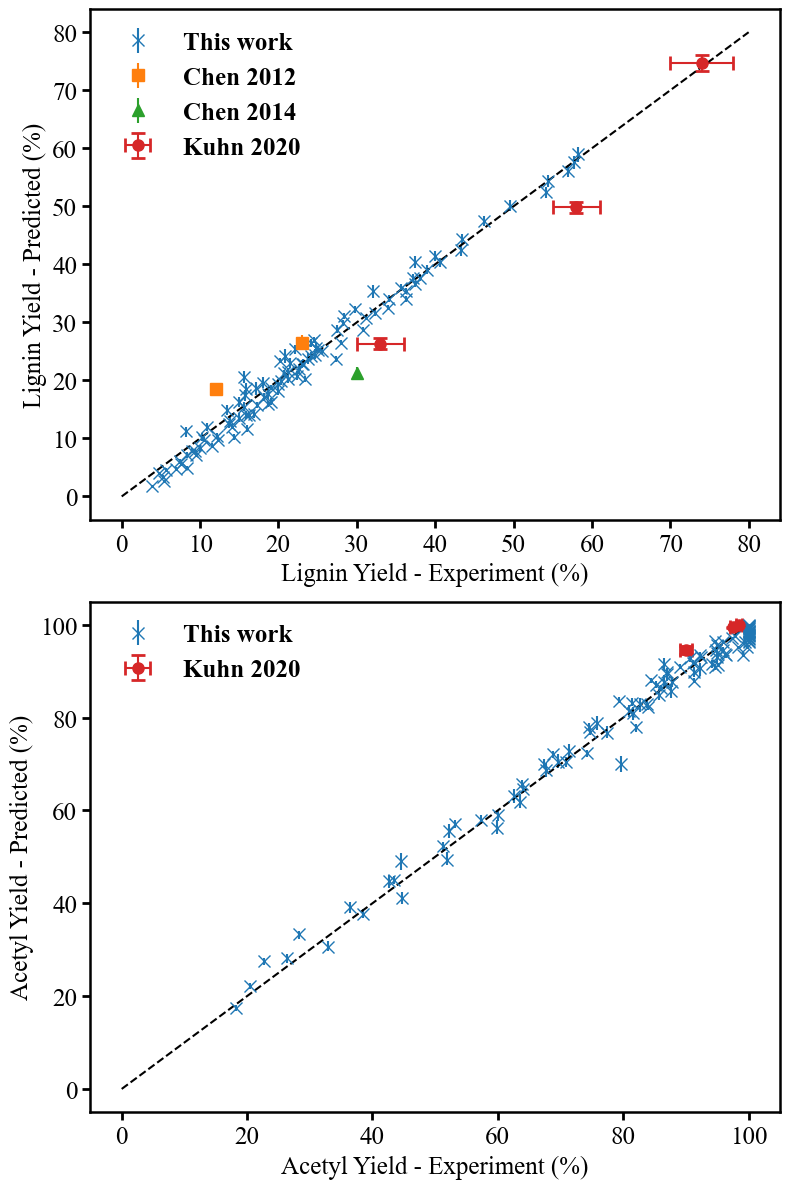

In [ ]:

save = True
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

axes[0].errorbar(exp_lignin_yield_colum_all*100, pred_lignin_yield_colum_all_avg*100, 
                 yerr=[(pred_lignin_yield_colum_all_avg - pred_lignin_yield_colum_all_low)*100, 
                       (pred_lignin_yield_colum_all_high - pred_lignin_yield_colum_all_avg)*100], 
                 fmt='x', markersize=8,  color='C0', label='This work')
axes[0].errorbar(np.array(exp_lignin_yield_lst_xchen2012)*100, np.array(pred_lignin_yield_lst_xchen2012_avg)*100, 
                 yerr=[(pred_lignin_yield_lst_xchen2012_avg - pred_lignin_yield_lst_xchen2012_low)*100, 
                       (pred_lignin_yield_lst_xchen2012_high - pred_lignin_yield_lst_xchen2012_avg)*100], 
                 fmt='s', markersize=8,  color='C1', label='Chen 2012')
axes[0].errorbar(np.array(exp_lignin_yield_lst_xchen2014)*100, np.array(pred_lignin_yield_lst_xchen2014_avg)*100, 
                 yerr=[(pred_lignin_yield_lst_xchen2014_avg - pred_lignin_yield_lst_xchen2014_low)*100, 
                       (pred_lignin_yield_lst_xchen2014_high - pred_lignin_yield_lst_xchen2014_avg)*100],
                 fmt='^', markersize=8,  color='C2', label='Chen 2014')
axes[0].errorbar(np.array(exp_lignin_yield_lst_kuhn2020)*100, np.array(pred_lignin_yield_lst_kuhn2020_avg)*100, 
                 yerr=[(pred_lignin_yield_lst_kuhn2020_avg - pred_lignin_yield_lst_kuhn2020_low)*100, 
                       (pred_lignin_yield_lst_kuhn2020_high - pred_lignin_yield_lst_kuhn2020_avg)*100],
                 xerr=np.array(exp_lignin_yield_lst_kuhn2020_std)*100, fmt='o', markersize=8, capsize=5, capthick=2, color='C3', label='Kuhn 2020')


axes[0].plot([0, 80], [0, 80], 'k--') # add parity line
axes[0].set_xlabel('Lignin Yield - Experiment (%)')
axes[0].set_ylabel('Lignin Yield - Predicted (%)')
axes[0].legend()

axes[1].errorbar(exp_acetyl_yield_colum_all*100, pred_acetyl_yield_colum_all_avg*100, 
                 yerr=[(pred_acetyl_yield_colum_all_avg - pred_acetyl_yield_colum_all_low)*100, 
                       (pred_acetyl_yield_colum_all_high - pred_acetyl_yield_colum_all_avg)*100],
                 fmt='x', markersize=8,  color='C0', label='This work')
axes[1].errorbar(np.array(exp_acetyl_yield_lst_kuhn2020)*100, np.array(pred_acetyl_yield_lst_kuhn2020_avg)*100, 
                 yerr=[(pred_acetyl_yield_lst_kuhn2020_avg - pred_acetyl_yield_lst_kuhn2020_low)*100, 
                       (pred_acetyl_yield_lst_kuhn2020_high - pred_acetyl_yield_lst_kuhn2020_avg)*100],
                 xerr=np.array(exp_acetyl_yield_lst_kuhn2020_std)*100, fmt='o', markersize=8, capsize=5, capthick=2, color='C3', label='Kuhn 2020')
axes[1].plot([0, 100], [0, 100], 'k--') # add parity line
axes[1].set_xlabel('Acetyl Yield - Experiment (%)')
axes[1].set_ylabel('Acetyl Yield - Predicted (%)')
axes[1].legend()


for ax in axes: 
    ax.legend(loc = 'best',prop={'size': 18, 'weight':'bold'},frameon=False,)
    
for ax in axes:
    ax.tick_params(axis = 'y', which = 'major', direction = 'out', length = 6.0, width = 2.0)
    ax.tick_params(axis = 'x', which = 'major', direction = 'out', length = 6.0, width = 2.0)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.8)
    fig.tight_layout()

if save:
    plt.savefig('./output/Parity_plot_lignin_acetyl_yield.png', dpi=300, bbox_inches='tight')

In [105]:
r2_lignin = r2_score(exp_lignin_yield_colum_all, pred_lignin_yield_colum_all_avg)
r2_acetyl = r2_score(exp_acetyl_yield_colum_all, pred_acetyl_yield_colum_all_avg)
print(f"R2 for Lignin Yield: {r2_lignin:.4f}") 
print(f"R2 for Acetyl Yield: {r2_acetyl:.4f}")

R2 for Lignin Yield: 0.9786
R2 for Acetyl Yield: 0.9864
